# AdaBoost | Banking loan default

AdaBoost raises the influence of previously misclassified training rows. Each weak learner contributes to the final vote.

**Goal:** Predict `loan_default` (1 = default, 0 = no default). All three notebooks use the same CSV, 80/20 stratified split, random seed, preprocessing and metrics. Results depend on the supplied data; no accuracy is promised. The example data is for teaching, not real lending decisions.

## 1. Setup

Python 3.11 is suitable. Install these packages once in your notebook environment. The first command is intentionally commented so it does not reinstall packages each run.

In [13]:
# %pip install pandas numpy matplotlib seaborn scikit-learn xgboost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay, log_loss
from sklearn.ensemble import AdaBoostClassifier

## 2. Read and inspect

Place `Banking_Loan_Default_Classification.csv` beside this notebook. Each row represents one loan applicant; `loan_default` is the answer the model learns to predict.


In [14]:
df = pd.read_csv("Banking_Loan_Default_Classification.csv")
print("Shape:", df.shape)
display(df.head())
print("Missing values:")
display(df.isna().sum().to_frame("missing"))
print("Target distribution:")
display(df["loan_default"].value_counts().sort_index().to_frame("count"))

Shape: (1000, 20)


,age,monthly_income_inr,employment_type,years_employed,education_level,marital_status,dependents,residence_type,years_at_address,loan_amount_inr,loan_term_months,loan_purpose,existing_loans,monthly_debt_payments_inr,credit_score,late_payments_last_12m,savings_balance_inr,account_tenure_years,has_guarantor,loan_default
0,32,56000,Self-employed,4,Graduate,Single,2,Family,2,990000,12,Medical,0,14000,678,0,265000,3,No,0
1,39,42000,Self-employed,11,Graduate,Single,0,Rented,21,100000,36,Education,2,17000,724,0,170000,3,No,0
2,60,60000,Self-employed,17,High school,Single,1,Family,16,240000,24,Home improvement,1,23000,641,1,225000,14,No,0
3,30,67000,Self-employed,0,Graduate,Single,0,Owned,12,890000,60,Vehicle,1,21000,597,1,95000,12,No,0
4,30,50000,Salaried,4,Postgraduate,Single,2,Owned,12,150000,60,Medical,1,11000,633,3,245000,12,Yes,1


Missing values:


,missing
age,0
monthly_income_inr,0
employment_type,0
years_employed,0
education_level,0
marital_status,0
dependents,0
residence_type,0
years_at_address,0
loan_amount_inr,0


Target distribution:


,count
loan_default,
0,613
1,387


## 3. Separate inputs and target; split before fitting preprocessing

`stratify=y` keeps the default proportion similar in training and test data. Fit imputers and encoding **only on training rows** through the pipeline, so test information cannot leak into training.

In [15]:
X = df.drop(columns="loan_default")
y = df["loan_default"]
assert set(y.unique()) == {0, 1}, "Expected 0/1 default labels"
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
print("Train:", X_train.shape, "Test:", X_test.shape)
print("Default rate, train:", round(y_train.mean(), 3))
print("Default rate, test:", round(y_test.mean(), 3))

Train: (800, 19) Test: (200, 19)
Default rate, train: 0.388
Default rate, test: 0.385


## 4. Prepare numerical and categorical columns

Numbers use median imputation. Text categories use most frequent imputation followed by one hot encoding. Unknown categories at prediction time are ignored safely.

In [16]:
numeric_columns = X.select_dtypes(include="number").columns.tolist()
categorical_columns = X.select_dtypes(exclude="number").columns.tolist()
print("Numeric:", numeric_columns)
print("Categorical:", categorical_columns)
numeric_pipe = Pipeline([("imputer", SimpleImputer(strategy="median"))])
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
preprocess = ColumnTransformer([
    ("numeric", numeric_pipe, numeric_columns),
    ("categorical", categorical_pipe, categorical_columns)
])

Numeric: ['age', 'monthly_income_inr', 'years_employed', 'dependents', 'years_at_address', 'loan_amount_inr', 'loan_term_months', 'existing_loans', 'monthly_debt_payments_inr', 'credit_score', 'late_payments_last_12m', 'savings_balance_inr', 'account_tenure_years']
Categorical: ['employment_type', 'education_level', 'marital_status', 'residence_type', 'loan_purpose', 'has_guarantor']


## 5. Train the model and display loss

AdaBoost does not expose Gradient Boosting’s `train_score_`. `staged_predict_proba` supplies training probabilities after each weak learner; we calculate binary log loss at every stage. This curve may rise at some stages and is not AdaBoost’s own optimization objective. Falling training loss alone does not prove generalization.


In [17]:
model = AdaBoostClassifier(n_estimators=150, learning_rate=0.05, random_state=42)
clf = Pipeline([("preprocess", preprocess), ("model", model)])
clf.fit(X_train, y_train)
print("Training complete")

Training complete


,stage,training_log_loss
0,1,0.549428
1,2,0.549428
2,3,0.440695
3,4,0.458150
4,5,0.430941
...,...,...
145,146,0.419686
146,147,0.419781
147,148,0.419872
148,149,0.420119


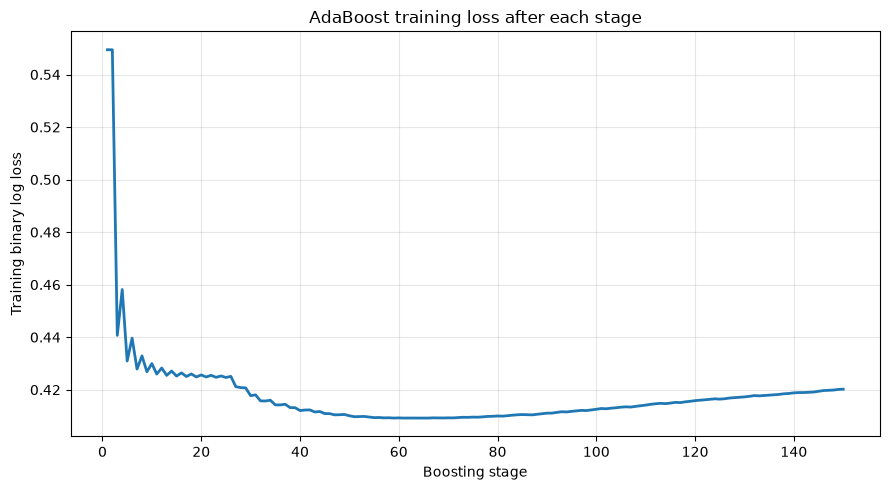

In [20]:
# Binary log loss on training data after each AdaBoost stage
X_train_ready = clf.named_steps["preprocess"].transform(X_train)
training_losses = []

for probabilities in clf.named_steps["model"].staged_predict_proba(X_train_ready):
    training_losses.append(log_loss(y_train, probabilities, labels=[0, 1]))

loss_history = pd.DataFrame({
    "stage": np.arange(1, len(training_losses) + 1),
    "training_log_loss": training_losses
})
from IPython.display import clear_output, display
import time
#print(loss_history.to_string(index=False))
for stage in range(1, len(loss_history) + 1):
    clear_output(wait=True)
    display(loss_history.iloc[:stage].round(6))
    time.sleep(0.2)
plt.figure(figsize=(9, 5))
plt.plot(loss_history["stage"], loss_history["training_log_loss"], linewidth=2)
plt.xlabel("Boosting stage")
plt.ylabel("Training binary log loss")
plt.title("AdaBoost training loss after each stage")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Predict and evaluate

For the positive class **default (1)**: precision = TP/(TP+FP), the fraction of predicted defaults that truly default; recall = TP/(TP+FN), the fraction of actual defaults found; F1 balances precision and recall. Accuracy measures all correct predictions / all cases. ROC AUC measures ranking across thresholds, not accuracy at one threshold.

In [7]:
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]
scores = pd.DataFrame({
    "metric": ["Accuracy", "Precision (default=1)", "Recall (default=1)", "F1 (default=1)", "ROC AUC"],
    "value": [accuracy_score(y_test,y_pred), precision_score(y_test,y_pred,zero_division=0), recall_score(y_test,y_pred,zero_division=0), f1_score(y_test,y_pred,zero_division=0), roc_auc_score(y_test,y_prob)]
})
display(scores.round(3))
print(classification_report(y_test, y_pred, target_names=["No default (0)","Default (1)"], zero_division=0))

,metric,value
0,Accuracy,0.845
1,Precision (default=1),0.838
2,Recall (default=1),0.740
3,F1 (default=1),0.786
4,ROC AUC,0.904


                precision    recall  f1-score   support

No default (0)       0.85      0.91      0.88       123
   Default (1)       0.84      0.74      0.79        77

      accuracy                           0.84       200
     macro avg       0.84      0.83      0.83       200
  weighted avg       0.84      0.84      0.84       200



## 7. Confusion matrix

Rows are **actual** and columns are **predicted**. Top left = TN, top right = FP, bottom left = FN, bottom right = TP. In lending, a false negative means an actual default was predicted as no default.

,Predicted no default (0),Predicted default (1)
Actual no default (0),112,11
Actual default (1),20,57


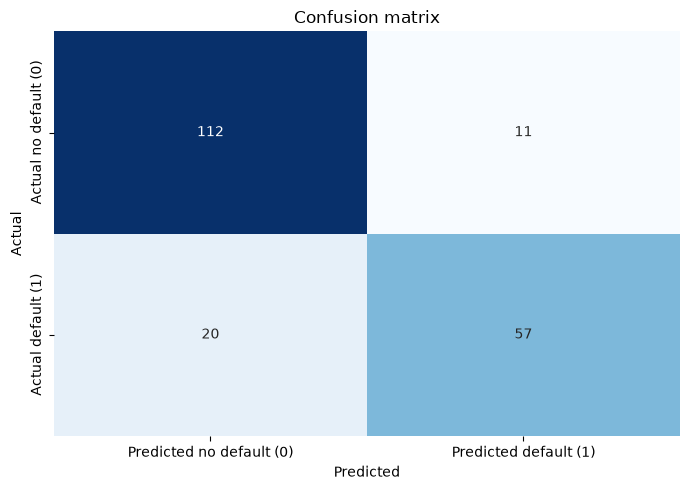

TN=112, FP=11, FN=20, TP=57


In [8]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
cm_table = pd.DataFrame(cm, index=["Actual no default (0)","Actual default (1)"], columns=["Predicted no default (0)","Predicted default (1)"])
display(cm_table)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm_table, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion matrix")
plt.tight_layout()
plt.show()
print(f"TN={cm[0,0]}, FP={cm[0,1]}, FN={cm[1,0]}, TP={cm[1,1]}")

## 8. ROC curve

A curve closer to the upper-left corner indicates stronger separation. The diagonal represents random ranking. This does not choose a business threshold for you.

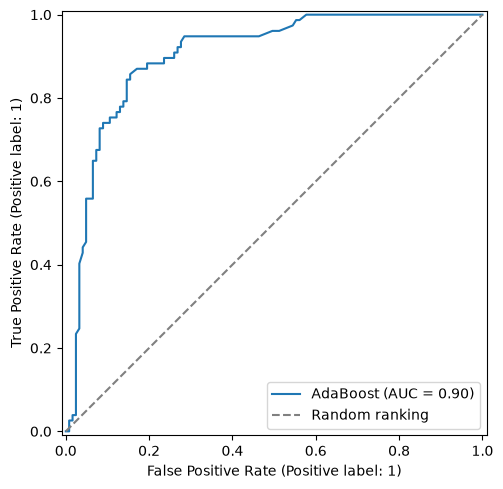

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax, name="AdaBoost")
ax.plot([0,1], [0,1], "--", color="gray", label="Random ranking")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Illustrative feature importance

These values describe what the fitted trees used, not causal effects. One hot columns are shown separately; importance definitions differ across boosting libraries, so do not compare raw values across notebooks.

,importance
numeric__credit_score,0.340678
numeric__late_payments_last_12m,0.318800
numeric__loan_amount_inr,0.196482
numeric__existing_loans,0.074057
numeric__monthly_income_inr,0.057435
categorical__education_level_Graduate,0.012549
numeric__dependents,0.000000
numeric__years_employed,0.000000
numeric__loan_term_months,0.000000
numeric__years_at_address,0.000000


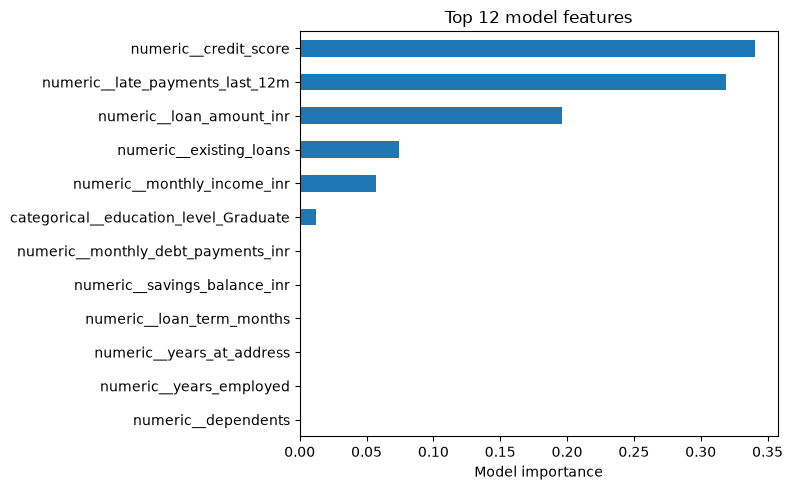

In [10]:
feature_names = clf.named_steps["preprocess"].get_feature_names_out()
importance = clf.named_steps["model"].feature_importances_
top_features = pd.Series(importance, index=feature_names).sort_values(ascending=False).head(12)
display(top_features.to_frame("importance"))
fig, ax = plt.subplots(figsize=(8, 5))
top_features.sort_values().plot.barh(ax=ax)
ax.set_title("Top 12 model features")
ax.set_xlabel("Model importance")
plt.tight_layout()
plt.show()

## 10. Predict one example and discuss

This example is drawn from the held-out test set. A probability is a model estimate, not a guarantee. To compare these three algorithms, run each notebook against the same CSV and compare the five metrics above; decide whether missing defaults (FN) or false alarms (FP) matter more.

In [11]:
one_applicant = X_test.iloc[[0]]
print("Actual label:", y_test.iloc[0])
print("Predicted label:", clf.predict(one_applicant)[0])
print("Estimated default probability:", round(clf.predict_proba(one_applicant)[0,1], 3))
display(one_applicant)

Actual label: 0
Predicted label: 0
Estimated default probability: 0.201


,age,monthly_income_inr,employment_type,years_employed,education_level,marital_status,dependents,residence_type,years_at_address,loan_amount_inr,loan_term_months,loan_purpose,existing_loans,monthly_debt_payments_inr,credit_score,late_payments_last_12m,savings_balance_inr,account_tenure_years,has_guarantor
754,61,60000,Salaried,21,High school,Married,0,Rented,9,340000,36,Vehicle,3,35000,675,0,5000,3,Yes
